# Temporal-Window Sensitivity (M6d)

Reruns candidate generation, scoring, ranking, event construction, and survival summaries for
several temporal windows (6/9/12/18 months) and compares each against the balanced reference.
**Running this notebook regenerates** `boamp_m0_links_window_*.csv`, `boamp_survival_m0_window_*.csv`
and the `m6d_*` tables under `reports/tables/`.

The linkage rule itself (scoring constants, CPV hierarchy score, survival-dataset construction) is
imported from `scripts/` so this notebook and the pipeline share a single definition.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from lifelines import KaplanMeierFitter
from lifelines.utils import restricted_mean_survival_time
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import build_m0_candidate_pairs as bmcp
import run_m0_linkage as rml

P = PROJECT_ROOT / "data" / "processed"
T = PROJECT_ROOT / "reports" / "tables"
T.mkdir(parents=True, exist_ok=True)

WINDOWS = [6, 9, 12, 18]
MAX_CAND = 30

## Load eligible sources, fit TF-IDF, and load the balanced reference links

In [2]:
dtype = {c: str for c in ["notice_id", "buyer_key", "buyer_key_type", "buyer_name_normalized",
                          "buyer_siret_clean", "buyer_siren_clean", "objet_clean", "cpv_clean",
                          "cpv_division", "cpv_category", "cpv_class", "cpv_group", "category_label"]}
all_sources = pd.read_csv(P / "boamp_m0_sources.csv", dtype=dtype,
                          parse_dates=["publication_date", "start_date", "estimated_end_date", "study_end_date"],
                          low_memory=False)
elig = all_sources[all_sources.buyer_key_type != "MISSING"].sort_values(
    ["buyer_key", "publication_date"]).reset_index(drop=True)
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2).fit_transform(
    elig.objet_clean.fillna("").tolist())

ref = pd.read_csv(P / "boamp_m0_links_balanced.csv",
                  dtype={"source_notice_id": str, "candidate_notice_id": str})
ref_keys = set(zip(ref.source_notice_id, ref.candidate_notice_id))
ref_src = set(ref.source_notice_id)
print(f"eligible sources: {len(elig)} | tfidf: {tfidf.shape} | reference links: {len(ref)}")

eligible sources: 3159 | tfidf: (3159, 7299) | reference links: 618


## Candidate generation for an arbitrary window

In [3]:
def build_pairs(src, tfidf, W):
    ids = src.notice_id.to_numpy()
    pub = src.publication_date.to_numpy()
    end = src.estimated_end_date.to_numpy()
    bk = src.buyer_key.to_numpy(object)
    bkt = src.buyer_key_type.to_numpy(object)
    main = src.cpv_clean.to_numpy(object)
    cat = src.cpv_category.to_numpy(object)
    cls = src.cpv_class.to_numpy(object)
    grp = src.cpv_group.to_numpy(object)
    div = src.cpv_division.to_numpy(object)
    gen = src.cpv_generic_flag.to_numpy()
    rec = []
    td = np.timedelta64(int(round(W * 30.44)), "D")
    for _, idx in src.groupby("buyer_key", sort=False).indices.items():
        idx = np.asarray(idx)
        gp = pub[idx]
        ge = end[idx]
        n = len(idx)
        if n < 2:
            continue
        for i in range(n):
            if pd.isna(ge[i]):
                continue
            lo = ge[i] - td
            hi = ge[i] + td
            left = np.searchsorted(gp, lo, "left")
            right = np.searchsorted(gp, hi, "right")
            loc = np.arange(left, right)
            loc = loc[(gp[loc] > gp[i]) & (loc != i)]
            if len(loc) == 0:
                continue
            glob = idx[loc]
            ig = idx[i]
            abs_gap = np.abs((gp[loc] - ge[i])) / np.timedelta64(1, "D") / 30.44
            if len(loc) > MAX_CAND:
                keep = np.argsort(abs_gap)[:MAX_CAND]
                loc = loc[keep]; glob = glob[keep]; abs_gap = abs_gap[keep]
            gaps = (gp[loc] - gp[i]) / np.timedelta64(1, "D") / 30.44
            stime = np.clip(1 - abs_gap / W, 0, None)
            sims = tfidf[glob].dot(tfidf[ig].T).toarray().ravel()
            sb = bmcp.BUYER_KEY_TYPE_SCORE.get(bkt[ig], 0.0)
            for k, cg in enumerate(glob):
                scpv = bmcp.cpv_pair_score(main[ig], main[cg], cat[ig], cat[cg], cls[ig], cls[cg],
                                           grp[ig], grp[cg], div[ig], div[cg])
                stext = float(sims[k])
                comp = bmcp.W_TEXT * stext + bmcp.W_CPV * scpv + bmcp.W_TIME * stime[k] + bmcp.W_BUYER * sb
                rec.append(dict(source_notice_id=ids[ig], candidate_notice_id=ids[cg],
                                source_date=gp[i], candidate_date=gp[loc[k]],
                                buyer_key=bk[ig], buyer_key_type=bkt[ig],
                                gap_months=gaps[k], expected_end_date=ge[i],
                                abs_gap_to_expected_end=abs_gap[k], s_time=stime[k],
                                s_text=stext, s_cpv=scpv, s_buyer=sb, m0_composite_score=comp,
                                cpv_missing=bool(pd.isna(main[ig]) or pd.isna(main[cg])),
                                cpv_generic_flag=bool(gen[ig] or gen[cg])))
    pairs = pd.DataFrame(rec)
    if len(pairs):
        pairs = pairs.sort_values(["source_notice_id", "m0_composite_score"], ascending=[True, False])
        pairs["candidate_rank"] = pairs.groupby("source_notice_id").cumcount() + 1
        pairs["n_candidates_for_source"] = pairs.groupby("source_notice_id").candidate_notice_id.transform("count")
        top2 = pairs[pairs.candidate_rank <= 2].pivot(index="source_notice_id", columns="candidate_rank",
                                                      values="m0_composite_score")
        margin = (top2.get(1) - top2.get(2)).fillna(top2.get(1))
        pairs["top1_top2_margin"] = pairs.source_notice_id.map(margin)
    return pairs


def km_summary(surv):
    km = KaplanMeierFitter()
    km.fit(surv.time_to_event_or_censor_months, surv.event)
    return float(km.survival_function_at_times(24).iloc[0]), float(restricted_mean_survival_time(km, t=60))

## Rerun the full chain per window

In [4]:
rows = []
by_year = []
by_seg = []
for W in WINDOWS:
    print(f"window {W}m")
    pairs = build_pairs(elig, tfidf, W)
    rank1 = pairs[pairs.candidate_rank == 1].copy() if len(pairs) else pairs
    thr = rank1.m0_composite_score.quantile(.5) if len(rank1) else np.nan
    links = rank1[rank1.m0_composite_score >= thr].copy() if len(rank1) else rank1.copy()
    links["variant"] = f"window_{W}m"
    links["threshold_used"] = thr
    links.to_csv(P / f"boamp_m0_links_window_{W}m.csv", index=False)
    surv = rml.build_survival_dataset(all_sources, links, f"window_{W}m")
    surv.to_csv(P / f"boamp_survival_m0_window_{W}m.csv", index=False)
    s24, rmst60 = km_summary(surv)
    keys = set(zip(links.source_notice_id, links.candidate_notice_id))
    src = set(links.source_notice_id)
    cnt = links.candidate_notice_id.value_counts()
    rows.append(dict(window_months=W, n_eligible_sources=len(elig),
                     n_sources_with_candidate=rank1.source_notice_id.nunique() if len(rank1) else 0,
                     blocking_coverage=(rank1.source_notice_id.nunique() / len(elig)) if len(elig) else np.nan,
                     n_candidate_pairs=len(pairs), n_links=len(links), linking_rate=len(links) / len(elig),
                     threshold_p50=thr, median_margin=rank1.top1_top2_margin.median() if len(rank1) else np.nan,
                     n_reused_candidates=int((cnt > 1).sum()),
                     max_candidate_multiplicity=int(cnt.max()) if len(cnt) else 0,
                     jaccard_vs_reference=len(keys & ref_keys) / len(keys | ref_keys) if keys | ref_keys else np.nan,
                     source_event_status_changes=len(src ^ ref_src),
                     survival_at_24m=s24, rmst_60m=rmst60,
                     mean_s_text=links.s_text.mean() if len(links) else np.nan,
                     mean_s_cpv=links.s_cpv.mean() if len(links) else np.nan,
                     mean_s_time=links.s_time.mean() if len(links) else np.nan,
                     mean_s_buyer=links.s_buyer.mean() if len(links) else np.nan))
    tmp = all_sources[["notice_id", "publication_date", "cpv_division", "buyer_key_type"]].merge(
        links[["source_notice_id"]], left_on="notice_id", right_on="source_notice_id", how="left")
    tmp["event"] = tmp.source_notice_id.notna()
    tmp["year"] = tmp.publication_date.dt.year
    for y, g in tmp[tmp.buyer_key_type != "MISSING"].groupby("year"):
        by_year.append(dict(window_months=W, publication_year=int(y), n_sources=len(g),
                            n_events=int(g.event.sum()), event_rate=g.event.mean()))
    for d, g in tmp[tmp.buyer_key_type != "MISSING"].groupby("cpv_division", dropna=False):
        by_seg.append(dict(window_months=W, cpv_division=d, n_sources=len(g),
                           n_events=int(g.event.sum()), event_rate=g.event.mean()))

sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(T / "m6d_temporal_window_sensitivity.csv", index=False)
pd.DataFrame(by_year).to_csv(T / "m6d_temporal_window_by_year.csv", index=False)
pd.DataFrame(by_seg).to_csv(T / "m6d_temporal_window_by_cpv_division.csv", index=False)
display(sensitivity)

window 6m


window 9m


window 12m


window 18m


,window_months,n_eligible_sources,n_sources_with_candidate,blocking_coverage,n_candidate_pairs,n_links,linking_rate,threshold_p50,median_margin,n_reused_candidates,max_candidate_multiplicity,jaccard_vs_reference,source_event_status_changes,survival_at_24m,rmst_60m,mean_s_text,mean_s_cpv,mean_s_time,mean_s_buyer
0,6,3159,1236,0.391263,6137,618,0.195632,0.323022,0.082718,121,6,1.000000,0,0.914059,53.513007,0.304767,0.295631,0.718757,0.689320
1,9,3159,1386,0.438746,8692,693,0.219373,0.334401,0.075181,131,6,0.736424,97,0.904885,52.801371,0.341088,0.338240,0.729524,0.690043
2,12,3159,1508,0.477366,10793,754,0.238683,0.344200,0.072816,149,8,0.578826,196,0.899389,52.222053,0.370732,0.381300,0.717672,0.693369
3,18,3159,1668,0.528015,14097,834,0.264008,0.354294,0.060582,155,9,0.453453,306,0.889917,51.361218,0.379972,0.414269,0.747084,0.692566


## How sensitive is the linkage to the window choice?

All three measures below are shares in [0, 1], so they sit on one axis: linking rate (events per
eligible source), blocking coverage (sources that get any candidate), and Jaccard overlap of the
resulting link set with the balanced reference.

In [5]:
import matplotlib.pyplot as plt

# Project palette (light mode) - identical to scripts/make_figures.py.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_PRIMARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "figure.dpi": 120,
})
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()

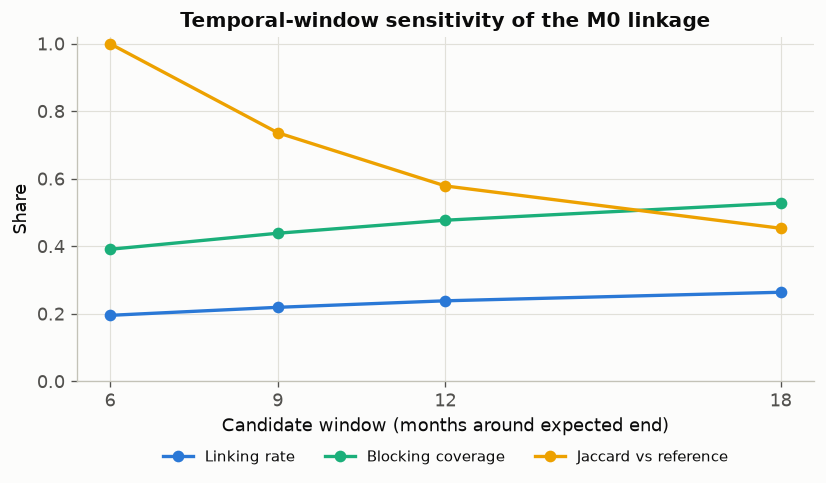

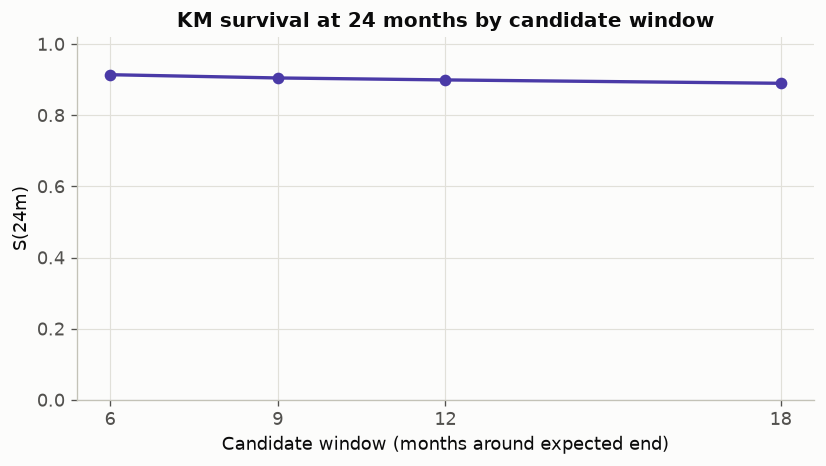

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2))
x = sensitivity["window_months"]
series = [
    ("linking_rate", "Linking rate", CAT["blue"]),
    ("blocking_coverage", "Blocking coverage", CAT["aqua"]),
    ("jaccard_vs_reference", "Jaccard vs reference", CAT["yellow"]),
]
for col, label, color in series:
    ax.plot(x, sensitivity[col], marker="o", linewidth=2, markersize=6, color=color, label=label)
ax.set_ylim(0, 1.02)
ax.set_xticks(list(x))
ax.set_title("Temporal-window sensitivity of the M0 linkage")
ax.set_xlabel("Candidate window (months around expected end)")
ax.set_ylabel("Share")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=9)
save_and_show(fig, "nb14_window_sensitivity")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, sensitivity["survival_at_24m"], marker="o", linewidth=2, markersize=6, color=CAT["violet"])
ax.set_ylim(0, 1.02)
ax.set_xticks(list(x))
ax.set_title("KM survival at 24 months by candidate window")
ax.set_xlabel("Candidate window (months around expected end)")
ax.set_ylabel("S(24m)")
save_and_show(fig, "nb14_survival24_by_window")

## Per-year and per-CPV-division event rates by window

In [7]:
by_year_df = pd.DataFrame(by_year)
display(by_year_df.pivot(index="publication_year", columns="window_months", values="event_rate").round(3))
by_seg_df = pd.DataFrame(by_seg)
display(by_seg_df.pivot(index="cpv_division", columns="window_months", values="event_rate").round(3))

window_months,6,9,12,18
publication_year,,,,
2015,0.308,0.361,0.395,0.429
2016,0.266,0.292,0.325,0.364
2017,0.332,0.351,0.354,0.370
2018,0.270,0.306,0.326,0.375
2019,0.217,0.242,0.280,0.309
2020,0.205,0.232,0.251,0.266
2021,0.134,0.141,0.147,0.170
2022,0.066,0.079,0.095,0.111
2023,0.035,0.035,0.042,0.053


window_months,6,9,12,18
cpv_division,,,,
NaN,0.318,0.343,0.340,0.359
09,0.000,0.000,0.000,0.000
16,0.000,0.000,0.000,0.000
22,0.000,0.333,0.333,0.333
30,0.118,0.133,0.167,0.202
31,0.200,0.200,0.200,0.000
32,0.114,0.130,0.151,0.189
33,0.700,0.700,0.700,0.700
34,0.000,0.000,0.000,0.000
